<img src="./Pics/MLSb-T.png" width="160">
<br><br>
<center><u><H1>Object Detection on images with YOLO</H1></u></center>

In [1]:
import cv2
from darkflow.net.build import TFNet
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'
import tensorflow as tf

In [2]:
config = tf.ConfigProto(log_device_placement=True)
config.gpu_options.allow_growth = True
with tf.Session(config=config) as sess:
    options = {
            'model': 'cfg/yolo.cfg',
            'load': 'bin/yolo.weights',
            'threshold': 0.1,
            'gpu': 1.0
                    }
    tfnet = TFNet(options)

Parsing ./cfg/yolo.cfg
Parsing cfg/yolo.cfg
Loading bin/yolo.weights ...
Successfully identified 203934260 bytes
Finished in 0.04706931114196777s
Model has a coco model name, loading coco labels.

Building net ...
Source | Train? | Layer description                | Output size
-------+--------+----------------------------------+---------------
Instructions for updating:
Colocations handled automatically by placer.
       |        | input                            | (?, 608, 608, 3)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 608, 608, 32)
 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 304, 304, 32)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 304, 304, 64)
 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 152, 152, 64)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 152, 152, 128)
 Load  |  Yep!  | conv 1x1p0_1  +bnorm  leaky      | (?, 152, 152, 64)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 152, 152, 128)
 Load  |  Ye

## Loading an Image with OpenCV

In [3]:
img = cv2.imread('./sample_img/image5_720.jpg', cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## Make Predictions with YOLO

In [4]:
img.shape

(406, 720, 3)

In [5]:
result = tfnet.return_predict(img)

In [6]:
result

[{'label': 'person',
  'confidence': 0.123621784,
  'topleft': {'x': 586, 'y': 259},
  'bottomright': {'x': 602, 'y': 279}},
 {'label': 'person',
  'confidence': 0.10321284,
  'topleft': {'x': 613, 'y': 260},
  'bottomright': {'x': 629, 'y': 280}},
 {'label': 'person',
  'confidence': 0.15693283,
  'topleft': {'x': 199, 'y': 271},
  'bottomright': {'x': 211, 'y': 297}},
 {'label': 'handbag',
  'confidence': 0.12633623,
  'topleft': {'x': 455, 'y': 269},
  'bottomright': {'x': 493, 'y': 356}},
 {'label': 'person',
  'confidence': 0.45495987,
  'topleft': {'x': 490, 'y': 259},
  'bottomright': {'x': 516, 'y': 355}},
 {'label': 'handbag',
  'confidence': 0.13782738,
  'topleft': {'x': 529, 'y': 269},
  'bottomright': {'x': 561, 'y': 350}},
 {'label': 'person',
  'confidence': 0.86730313,
  'topleft': {'x': 389, 'y': 258},
  'bottomright': {'x': 438, 'y': 392}},
 {'label': 'person',
  'confidence': 0.7839378,
  'topleft': {'x': 453, 'y': 262},
  'bottomright': {'x': 501, 'y': 384}},
 {'lab

## Adding Predictions to the image

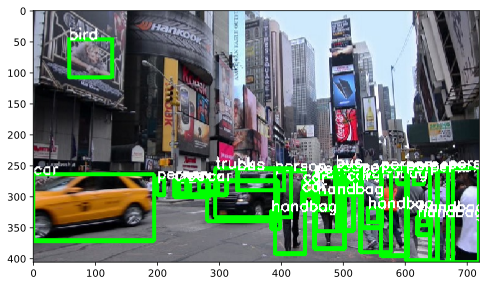

In [7]:
plt.figure(figsize=(8,12))
for r in result:   
    tl = (r['topleft']['x'], r['topleft']['y'])
    br = (r['bottomright']['x'], r['bottomright']['y'])
    label = r['label']

    img = cv2.rectangle(img, tl, br, (0, 255, 0), 5)
    img = cv2.putText(img, label, tl, cv2.FONT_ITALIC, 0.8, (255, 255, 255), 2)

plt.imshow(img)
plt.show()

## Detecting objects in a group of images:

In [8]:
import os

In [9]:
folder = './sample_img/'

In [10]:
path = os.path.join(folder)

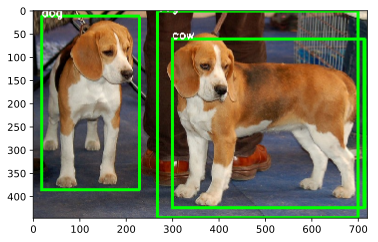

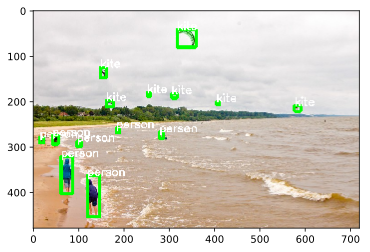

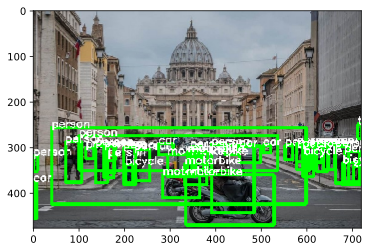

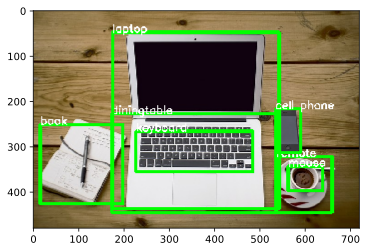

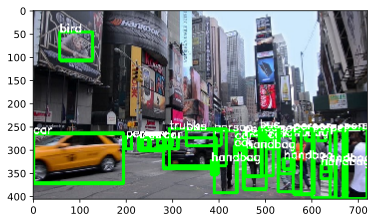

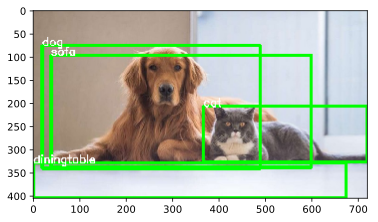

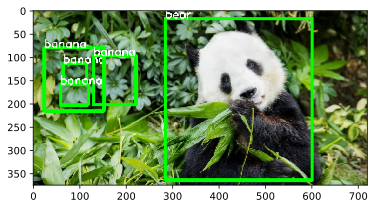

error: OpenCV(3.4.5) D:\Build\OpenCV\opencv-3.4.5\modules\imgproc\src\color.cpp:181: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [11]:
for image in os.listdir(path):
    img1 = cv2.imread(os.path.join(path,image), cv2.IMREAD_COLOR)
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

    result = tfnet.return_predict(img1) 
    
    for r in result:   
        tl = (r['topleft']['x'], r['topleft']['y'])
        br = (r['bottomright']['x'], r['bottomright']['y'])
        label = r['label']
        img1 = cv2.rectangle(img1, tl, br, (0, 255, 0), 6)
        #image, tof-left coordinates, bottom right coordinates, line color, thickness
        img1 = cv2.putText(img1, label, tl, cv2.FONT_ITALIC, 0.8, (255, 255, 255), 2) 
        #image, label, tof-left coordinates, font, font size, font color, linetype 
    plt.imshow(img1)
    plt.show()       